In [2]:
# Cell 0 - Environment & reproducibility
import os, random, json, joblib, math, datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)

pd.options.display.max_columns = 200
plt.rcParams['figure.figsize'] = (9,6)


In [3]:
# Cell 1 - Paths, config, and assumptions
DATA_PATH = 'synthetic_academic_dataset_v2.csv'   # dataset path (use as URL)

# Label config - change if your target column differs
LABEL_COL = 'label'    # expected binary: 0 (low), 1 (high)
ID_COL = 'id'          # change to your id column name if exists, else set to None

# Pipeline config
USE_SMOTE = True       # True = SMOTE oversampling of minority class; False = class weights
TEST_SIZE = 0.20
CV_FOLDS = 5
SAVE_DIR = 'Data/model_artifacts'
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)


In [4]:
# Cell 1 - Load data
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
display(df.head())
print('\nColumns:', df.columns.tolist())
print('\nMissing values per column:')
print(df.isna().sum())


Dataset shape: (4108, 30)


,Age,Sleep_Hours,Screen_Time,Stress_Level,Noise_Exposure,Social_Interaction,Work_Hours,Exercise_Hours,Caffeine_Intake,Multitasking_Habit,Anxiety_Score,Depression_Score,Sensory_Sensitivity,Meditation_Habit,Overthinking_Score,Irritability_Score,Headache_Frequency,Sleep_Quality,Tech_Usage_Hours,Overstimulated,Heart_Rate,GPA,Prev_GPA,GPA_trend,Modules,Assignments_total,Deadlines_next_7_days,Assignment_weight_avg_pct,Study_hours_per_day,Attendance_pct
0,25,7.963324,3.315576,7,2,8,13,1.217663,3,1,3,4,0,1,4,4,2,1,9.131087,0,83.4,2.49,2.66,-0.17,5,12,1,50.8,1.98,77.1
1,28,6.384820,2.704178,7,2,5,4,0.212013,1,1,4,4,2,0,7,9,4,3,1.786597,0,84.5,2.38,2.36,0.02,5,12,1,45.1,1.78,65.2
2,28,8.641948,1.910105,5,4,8,8,1.622918,1,0,4,1,2,0,1,8,4,3,9.492482,0,76.3,2.75,2.67,0.08,5,12,1,42.1,4.06,69.9
3,20,7.211283,2.508633,5,1,5,11,0.319535,2,0,4,6,1,1,4,6,5,3,2.885012,0,84.8,2.56,2.76,-0.20,5,7,1,45.1,3.33,74.9
4,19,9.189445,6.560596,9,3,1,14,2.713131,2,1,6,9,2,1,7,4,2,1,4.166018,1,86.5,2.40,2.87,-0.47,4,15,3,57.3,1.89,66.3



Columns: ['Age', 'Sleep_Hours', 'Screen_Time', 'Stress_Level', 'Noise_Exposure', 'Social_Interaction', 'Work_Hours', 'Exercise_Hours', 'Caffeine_Intake', 'Multitasking_Habit', 'Anxiety_Score', 'Depression_Score', 'Sensory_Sensitivity', 'Meditation_Habit', 'Overthinking_Score', 'Irritability_Score', 'Headache_Frequency', 'Sleep_Quality', 'Tech_Usage_Hours', 'Overstimulated', 'Heart_Rate', 'GPA', 'Prev_GPA', 'GPA_trend', 'Modules', 'Assignments_total', 'Deadlines_next_7_days', 'Assignment_weight_avg_pct', 'Study_hours_per_day', 'Attendance_pct']

Missing values per column:
Age                          0
Sleep_Hours                  0
Screen_Time                  0
Stress_Level                 0
Noise_Exposure               0
Social_Interaction           0
Work_Hours                   0
Exercise_Hours               0
Caffeine_Intake              0
Multitasking_Habit           0
Anxiety_Score                0
Depression_Score             0
Sensory_Sensitivity          0
Meditation_Habit  

In [5]:
# Cell 2 - Feature selection for burnout scoring
# List columns from your dataset (adjust if names differ)
candidate_features = [
 'Stress_Level','Anxiety_Score','Depression_Score','Overthinking_Score',
 'Sleep_Hours','Sleep_Quality','GPA_trend','Attendance_pct','Overstimulated',
 'Caffeine_Intake','Tech_Usage_Hours','Assignments_total','Deadlines_next_7_days'
]

# Verify they exist
for c in candidate_features:
    if c not in df.columns:
        raise ValueError(f"Expected column '{c}' not found. Adjust candidate_features list.")

display(df[candidate_features].describe().T)


,count,mean,std,min,25%,50%,75%,max
Stress_Level,4108.0,5.016310,2.380625,1.000000,3.000000,5.000000,7.000000,9.000000
Anxiety_Score,4108.0,5.138023,2.428964,1.000000,3.000000,5.000000,7.000000,9.000000
Depression_Score,4108.0,4.962999,2.303932,1.000000,3.000000,5.000000,7.000000,9.000000
Overthinking_Score,4108.0,5.028481,2.387965,1.000000,3.000000,5.000000,7.000000,9.000000
Sleep_Hours,4108.0,6.341444,1.912328,3.010317,4.929387,6.284376,7.803242,9.984746
Sleep_Quality,4108.0,2.532132,1.015674,1.000000,2.000000,3.000000,3.000000,4.000000
GPA_trend,4108.0,-0.001159,0.179091,-0.610000,-0.120000,0.000000,0.120000,0.600000
Attendance_pct,4108.0,74.825803,7.169961,49.300000,69.800000,74.900000,79.700000,99.500000
Overstimulated,4108.0,0.642405,0.479350,0.000000,0.000000,1.000000,1.000000,1.000000
Caffeine_Intake,4108.0,1.961052,1.273216,0.000000,1.000000,2.000000,3.000000,4.000000


In [6]:
# Cell 3 - Create weighted burnout score (Method 1)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Copy to avoid changing original
df_scored = df.copy()

# Define weights (tweakable). Sum should be 1.0
weights = {
    'Stress_Level': 0.18,
    'Anxiety_Score': 0.18,
    'Depression_Score': 0.15,
    'Overthinking_Score': 0.10,
    'Sleep_Hours': -0.10,        # negative weight because low sleep contributes to burnout
    'Sleep_Quality': -0.08,      # low quality contributes to burnout
    'GPA_trend': -0.08,          # decreasing GPA -> negative trend indicates burnout
    'Attendance_pct': -0.05,     # lower attendance -> burnout proxy
    'Overstimulated': 0.04,
    'Caffeine_Intake': 0.02,
    'Tech_Usage_Hours': 0.02,
    'Assignments_total': 0.02,
    'Deadlines_next_7_days': 0.02
}

# Build score: standardize each used feature, multiply by weight, sum, then scale 0-100
feat_cols = list(weights.keys())

scaler = StandardScaler()
Z = scaler.fit_transform(df_scored[feat_cols])
Z_df = pd.DataFrame(Z, columns=feat_cols)
# weighted sum
weighted = np.zeros(len(df_scored))
for col, w in weights.items():
    weighted += Z_df[col].values * w

# scale to 0-100 via MinMax
mm = MinMaxScaler(feature_range=(0,100))
score_0_100 = mm.fit_transform(weighted.reshape(-1,1)).ravel()
df_scored['burnout_score'] = score_0_100

# Threshold to binary / ternary labels
# Binary threshold default at 60 (tunable)
BINARY_THRESHOLD = 60.0
df_scored['burnout_label_binary'] = (df_scored['burnout_score'] >= BINARY_THRESHOLD).astype(int)

# Ternary (optional)
LOW_HI_THRESH = (40.0, 70.0)  # <40 low, 40-70 medium, >=70 high
def ternary_label(s):
    if s < LOW_HI_THRESH[0]:
        return 0
    elif s < LOW_HI_THRESH[1]:
        return 1
    else:
        return 2
df_scored['burnout_label_ternary'] = df_scored['burnout_score'].apply(ternary_label)

# Show summary
print(df_scored['burnout_score'].describe())
print('Binary counts:\n', df_scored['burnout_label_binary'].value_counts())
print('Ternary counts:\n', df_scored['burnout_label_ternary'].value_counts())
display(df_scored[['burnout_score','burnout_label_binary','burnout_label_ternary']].head())


count    4108.000000
mean       50.703037
std        15.548235
min         0.000000
25%        39.930353
50%        50.676093
75%        61.308751
max       100.000000
Name: burnout_score, dtype: float64
Binary counts:
 burnout_label_binary
0    2966
1    1142
Name: count, dtype: int64
Ternary counts:
 burnout_label_ternary
1    2629
0    1034
2     445
Name: count, dtype: int64


,burnout_score,burnout_label_binary,burnout_label_ternary
0,48.957334,0,1
1,50.145837,0,1
2,20.563339,0,0
3,43.662241,0,1
4,92.812744,1,2


In [7]:
# Cell 4 - Clustering + heuristic mapping (KMeans)
from sklearn.cluster import KMeans
cluster_features = feat_cols  # same set as above
Xc = df[cluster_features].copy()
Xc = (Xc - Xc.mean()) / Xc.std()   # simple standardization

# Choose k=3 clusters to try to get low/medium/high groups
k = 3
km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
clusters = km.fit_predict(Xc)
df_clustered = df.copy()
df_clustered['cluster'] = clusters

# Evaluate cluster centroids and map cluster->burnout based on centroid severity
centers = pd.DataFrame(km.cluster_centers_, columns=cluster_features)
# compute a simple severity metric per cluster — weighted like before (use abs of negative signs)
severity_weights = {c: abs(weights.get(c, 0.01)) for c in cluster_features}
centers['severity_score'] = centers.apply(lambda row: sum(row[c]*severity_weights[c] for c in cluster_features), axis=1)
centers = centers.sort_values('severity_score', ascending=False)
centers['mapped_label'] = [2,1,0][:len(centers)]  # highest severity->2 (high), next->1, lowest->0
centers = centers.reset_index().rename(columns={'index':'cluster_id'})
print(centers[['cluster_id','severity_score','mapped_label']])
# create mapping dict
cluster_to_label = dict(zip(centers['cluster_id'], centers['mapped_label']))
df_clustered['burnout_label_cluster'] = df_clustered['cluster'].map(cluster_to_label)

print('Cluster label counts:', df_clustered['burnout_label_cluster'].value_counts())
display(df_clustered.head())


   cluster_id  severity_score  mapped_label
0           2        0.090745             2
1           1        0.066656             1
2           0       -0.142228             0
Cluster label counts: burnout_label_cluster
0    1454
1    1413
2    1241
Name: count, dtype: int64


,Age,Sleep_Hours,Screen_Time,Stress_Level,Noise_Exposure,Social_Interaction,Work_Hours,Exercise_Hours,Caffeine_Intake,Multitasking_Habit,Anxiety_Score,Depression_Score,Sensory_Sensitivity,Meditation_Habit,Overthinking_Score,Irritability_Score,Headache_Frequency,Sleep_Quality,Tech_Usage_Hours,Overstimulated,Heart_Rate,GPA,Prev_GPA,GPA_trend,Modules,Assignments_total,Deadlines_next_7_days,Assignment_weight_avg_pct,Study_hours_per_day,Attendance_pct,cluster,burnout_label_cluster
0,25,7.963324,3.315576,7,2,8,13,1.217663,3,1,3,4,0,1,4,4,2,1,9.131087,0,83.4,2.49,2.66,-0.17,5,12,1,50.8,1.98,77.1,2,2
1,28,6.384820,2.704178,7,2,5,4,0.212013,1,1,4,4,2,0,7,9,4,3,1.786597,0,84.5,2.38,2.36,0.02,5,12,1,45.1,1.78,65.2,2,2
2,28,8.641948,1.910105,5,4,8,8,1.622918,1,0,4,1,2,0,1,8,4,3,9.492482,0,76.3,2.75,2.67,0.08,5,12,1,42.1,4.06,69.9,2,2
3,20,7.211283,2.508633,5,1,5,11,0.319535,2,0,4,6,1,1,4,6,5,3,2.885012,0,84.8,2.56,2.76,-0.20,5,7,1,45.1,3.33,74.9,0,0
4,19,9.189445,6.560596,9,3,1,14,2.713131,2,1,6,9,2,1,7,4,2,1,4.166018,1,86.5,2.40,2.87,-0.47,4,15,3,57.3,1.89,66.3,1,1


In [8]:
# Cell 5 - Choose label source
# Options: 'weighted' (method 1 binary), 'ternary' (method1 3-class), 'cluster' (method2)
LABEL_CHOICE = 'weighted'   # change to 'ternary' or 'cluster' as desired

if LABEL_CHOICE == 'weighted':
    df['burnout_label'] = df_scored['burnout_label_binary']
    df['burnout_score'] = df_scored['burnout_score']
elif LABEL_CHOICE == 'ternary':
    df['burnout_label'] = df_scored['burnout_label_ternary']
    df['burnout_score'] = df_scored['burnout_score']
elif LABEL_CHOICE == 'cluster':
    df['burnout_label'] = df_clustered['burnout_label_cluster']
else:
    raise ValueError('Unknown LABEL_CHOICE: pick weighted / ternary / cluster')

print('Using label choice:', LABEL_CHOICE)
print('Label distribution:')
print(df['burnout_label'].value_counts(normalize=False))
display(df[[c for c in df.columns if 'burnout' in c]].head())


Using label choice: weighted
Label distribution:
burnout_label
0    2966
1    1142
Name: count, dtype: int64


,burnout_label,burnout_score
0,0,48.957334
1,0,50.145837
2,0,20.563339
3,0,43.662241
4,1,92.812744


burnout_label,0,1
Stress_Level,4.367498,6.701401
Anxiety_Score,4.594403,6.549912
Depression_Score,4.553608,6.026270
Overthinking_Score,4.727242,5.810858
Sleep_Hours,6.605065,5.656768
Sleep_Quality,2.623061,2.295972
GPA_trend,0.016295,-0.046489
Attendance_pct,76.255226,71.113310
Overstimulated,0.612272,0.720665
Caffeine_Intake,1.931558,2.037653


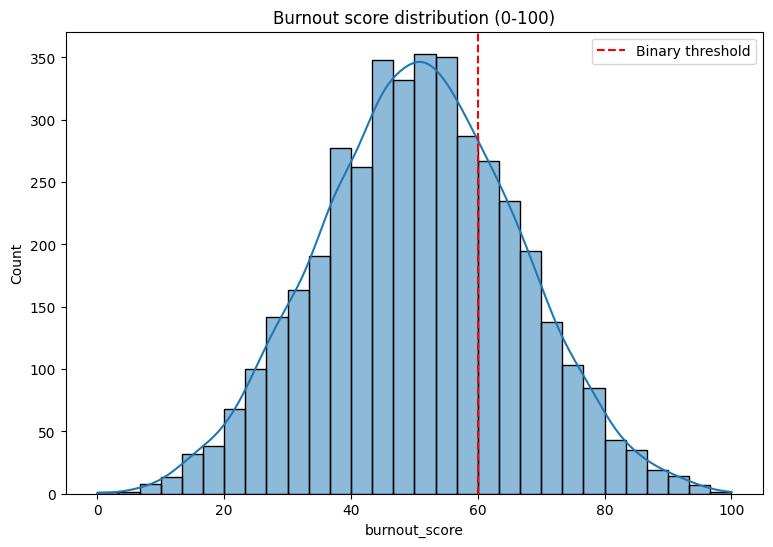

In [9]:
# Cell 6 - Sanity checks: look at feature means by label
label_col = 'burnout_label'
grouped = df.groupby(label_col)[candidate_features].mean().T
display(grouped)

# Plot burnout_score distribution
if 'burnout_score' in df.columns:
    sns.histplot(df['burnout_score'], bins=30, kde=True)
    plt.title('Burnout score distribution (0-100)')
    plt.axvline(BINARY_THRESHOLD, color='r', linestyle='--', label='Binary threshold')
    plt.legend()
    plt.show()


In [10]:
# Cell 7 - Prepare feature matrix and split
FEATURES = [c for c in df.columns if c not in ['burnout_label','burnout_score','burnout_label_binary','burnout_label_ternary','cluster']]
# optionally drop columns not to be used (e.g., ID)
# FEATURES = [f for f in FEATURES if f not in ['id', 'text_column']]

X = df[FEATURES].copy()
y = df['burnout_label'].copy()

# If ternary chosen ensure proper dtype
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train label counts:\n', y_train.value_counts())


Train shape: (3286, 30) Test shape: (822, 30)
Train label counts:
 burnout_label
0    2373
1     913
Name: count, dtype: int64


In [11]:
# Cell 8 - Preprocessing and pipeline set up (FIXED VERSION)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# Numeric processing: impute + scale
num_transform = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical processing (FIXED replacement for sparse=)
cat_transform = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_transform, num_cols),
    ('cat', cat_transform, cat_cols)
], remainder='drop')

# SMOTE enable/disable
USE_SMOTE = True
smote_step = ('smote', SMOTE(random_state=RANDOM_STATE)) if USE_SMOTE else ('smote', 'passthrough')

print("Preprocessing pipeline built successfully!")


Preprocessing pipeline built successfully!


In [12]:
# Cell 9 - Build baseline pipelines
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

pipe_lr = ImbPipeline(steps=[
    ('pre', preprocessor),
    smote_step,
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced' if not USE_SMOTE else None))
])

pipe_gb = ImbPipeline(steps=[
    ('pre', preprocessor),
    smote_step,
    ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

pipe_rf = ImbPipeline(steps=[
    ('pre', preprocessor),
    smote_step,
    ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])

print('Pipelines ready.')


Pipelines ready.


In [13]:
# Cell 10 - CV baseline scores
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy','precision','recall','f1','roc_auc'] if len(y.unique())==2 else ['accuracy','precision_macro','recall_macro','f1_macro']

def cv_print(pipe):
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1)
    for k,v in res.items():
        if k.startswith('test_'):
            print(k, np.mean(v), np.std(v))
    print('---')

print('LogisticRegression CV:')
cv_print(pipe_lr)
print('GradientBoosting CV:')
cv_print(pipe_gb)
print('RandomForest CV:')
cv_print(pipe_rf)


LogisticRegression CV:
test_accuracy 0.9863050709451174 0.004617892919024382
test_precision 0.9640818879529304 0.018054667415655076
test_recall 0.9879421125322765 0.008768784778973504
test_f1 0.9757233411164842 0.008050247846450125
test_roc_auc 0.9994780351467151 0.000328097025700247
---
GradientBoosting CV:
test_accuracy 0.9363964414095569 0.009104544012192028
test_precision 0.8844625439216465 0.02763930629374915
test_recall 0.8882903981264636 0.018744614455403635
test_f1 0.8860020952323749 0.015242410370649134
test_roc_auc 0.9832104111380658 0.0030239824800668332
---
RandomForest CV:
test_accuracy 0.9038329331538308 0.005670205752022273
test_precision 0.8574870454649414 0.023446306408909236
test_recall 0.7853419804239475 0.014135029965776612
test_f1 0.819493526113613 0.008733029286965373
test_roc_auc 0.9606470651703883 0.0033419822203346952
---


In [14]:
# Cell 11 (fixed) - Hyperparameter tuning (Randomized search for GB and LR)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# LR param: C in approx [0.01, 10.01)
lr_params = {'clf__C': uniform(0.01, 10.0)}

# GB params - NOTE: uniform(loc, scale) -> samples in [loc, loc+scale)
# Make subsample use uniform(0.6, 0.4) so sampled values are in [0.6, 1.0)
gb_params = {
    'clf__n_estimators': randint(50, 400),
    'clf__learning_rate': uniform(0.01, 0.19),  # [0.01, 0.20)
    'clf__max_depth': randint(2, 8),
    'clf__subsample': uniform(0.6, 0.4)          # [0.6, 1.0)
}

n_iter = 30  # reduce to 20 if you'd like faster runs

rs_lr = RandomizedSearchCV(
    pipe_lr,
    lr_params,
    n_iter=n_iter,
    scoring='f1' if len(y.unique()) == 2 else 'f1_macro',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    error_score='raise'   # raise exceptions during debugging so you see exact errors
)

rs_gb = RandomizedSearchCV(
    pipe_gb,
    gb_params,
    n_iter=n_iter,
    scoring='f1' if len(y.unique()) == 2 else 'f1_macro',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

print('Fitting LR random search...')
rs_lr.fit(X_train, y_train)
print('Best LR', rs_lr.best_score_, rs_lr.best_params_)

print('Fitting GB random search...')
rs_gb.fit(X_train, y_train)
print('Best GB', rs_gb.best_score_, rs_gb.best_params_)


Fitting LR random search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best LR 0.9826150159740751 {'clf__C': np.float64(9.51714306409916)}
Fitting GB random search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best GB 0.9248338183218324 {'clf__learning_rate': np.float64(0.16359549614212762), 'clf__max_depth': 2, 'clf__n_estimators': 395, 'clf__subsample': np.float64(0.6390688456025535)}


== Best LR ==
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       593
           1       1.00      1.00      1.00       229

    accuracy                           1.00       822
   macro avg       1.00      1.00      1.00       822
weighted avg       1.00      1.00      1.00       822

Confusion matrix:
 [[593   0]
 [  1 228]]
ROC AUC: 0.9999779082012121


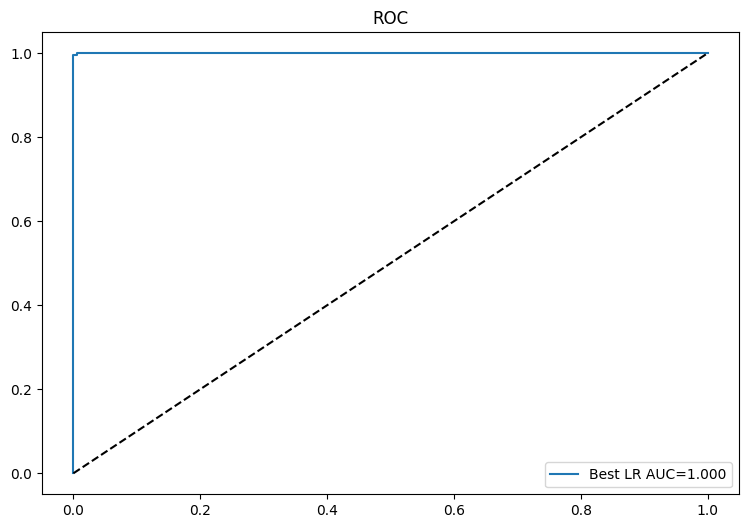

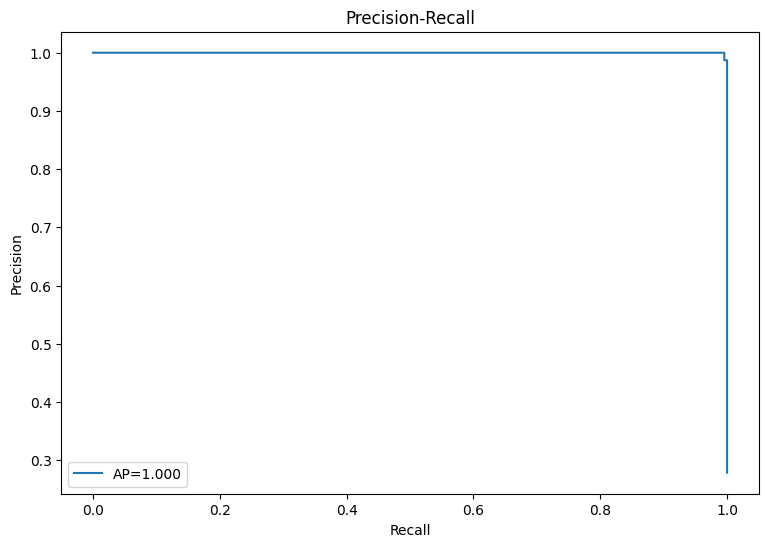

== Best GB ==
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       593
           1       0.95      0.93      0.94       229

    accuracy                           0.97       822
   macro avg       0.96      0.95      0.96       822
weighted avg       0.97      0.97      0.97       822

Confusion matrix:
 [[581  12]
 [ 16 213]]
ROC AUC: 0.9953165386569659


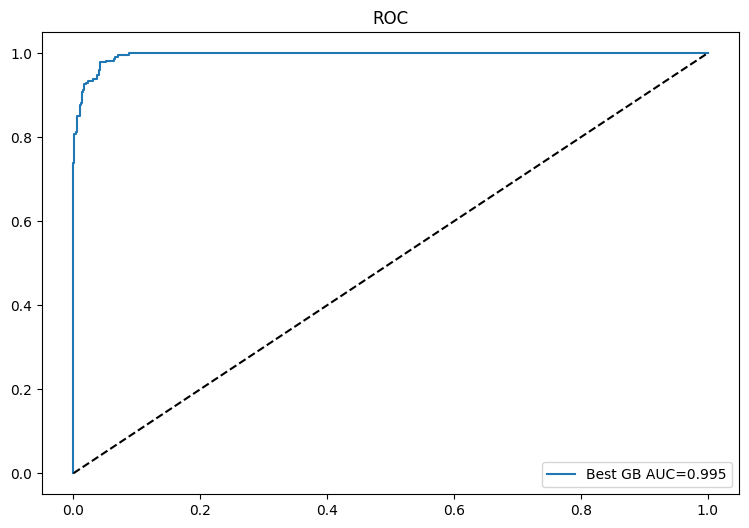

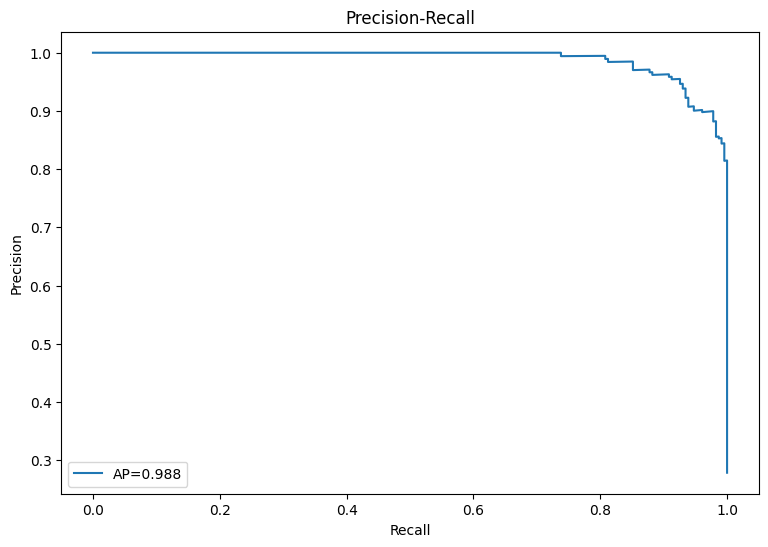

In [15]:
# Cell 12 - Test set evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

best_lr = rs_lr.best_estimator_
best_gb = rs_gb.best_estimator_

def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f'== {name} ==')
    print(classification_report(y_test, y_pred))
    print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))
    if len(np.unique(y_test))==2 and hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:,1]
        print('ROC AUC:', roc_auc_score(y_test, y_proba))
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} AUC={roc_auc_score(y_test,y_proba):.3f}')
        plt.plot([0,1],[0,1],'k--'); plt.title('ROC'); plt.legend(); plt.show()
        p, r, _ = precision_recall_curve(y_test, y_proba)
        ap = average_precision_score(y_test, y_proba)
        plt.plot(r, p, label=f'AP={ap:.3f}'); plt.title('Precision-Recall'); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.legend(); plt.show()

evaluate('Best LR', best_lr, X_test, y_test)
evaluate('Best GB', best_gb, X_test, y_test)


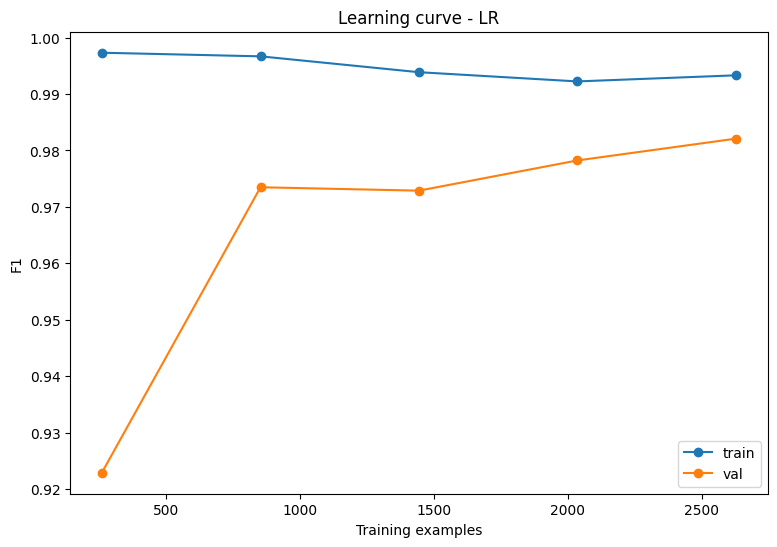

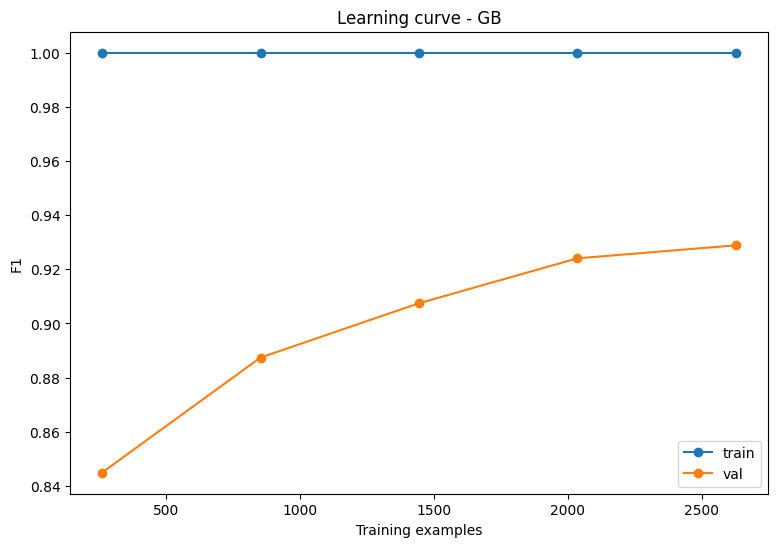

In [16]:
# Cell 13 - Learning curves
from sklearn.model_selection import learning_curve

def plot_learning(estimator, title):
    train_sizes, train_scores, val_scores = learning_curve(estimator, X_train, y_train, cv=cv,
                                                           scoring='f1' if len(y.unique())==2 else 'f1_macro',
                                                           n_jobs=-1, train_sizes=np.linspace(0.1,1.0,5))
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    plt.plot(train_sizes, train_mean, 'o-', label='train')
    plt.plot(train_sizes, val_mean, 'o-', label='val')
    plt.title(title); plt.xlabel('Training examples'); plt.ylabel('F1'); plt.legend(); plt.show()

plot_learning(best_lr, 'Learning curve - LR')
plot_learning(best_gb, 'Learning curve - GB')


In [17]:
# # Combined confusion matrix: numeric + text labels
# plt.figure(figsize=(8,6))
# ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                  xticklabels=['Pred 0', 'Pred 1'],
#                  yticklabels=['Actual 0', 'Actual 1'])

# # Add TP/TN/FP/FN text manually on top
# group_names = ["TN","FP","FN","TP"]
# for i in range(2):
#     for j in range(2):
#         ax.text(j+0.02, i+0.65, group_names[i*2+j],
#                 color='red', fontsize=12, fontweight='bold')

# plt.title("Confusion Matrix with TP / FP / FN / TN Labels")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()


=== Logistic Regression - Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       593
           1       1.00      1.00      1.00       229

    accuracy                           1.00       822
   macro avg       1.00      1.00      1.00       822
weighted avg       1.00      1.00      1.00       822


Logistic Regression - Confusion Matrix (numeric):
 [[593   0]
 [  1 228]]


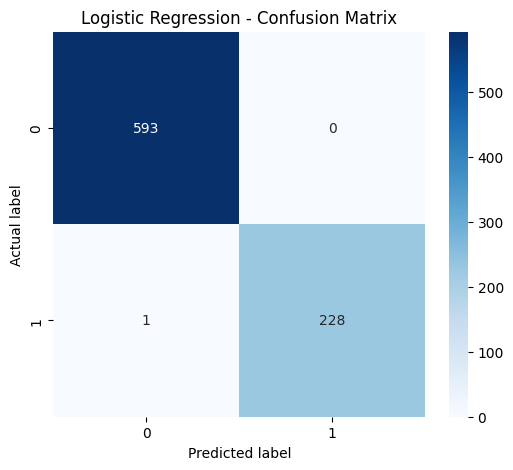

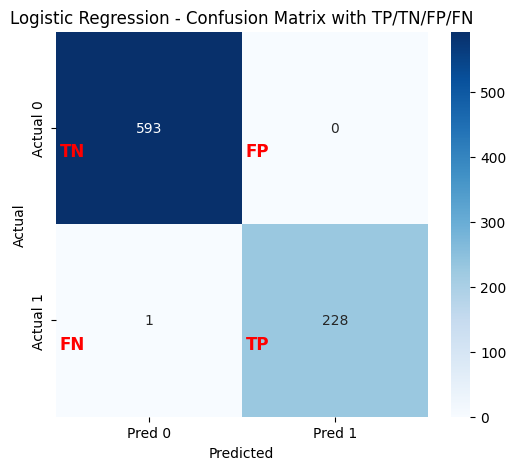

=== Gradient Boosting - Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       593
           1       0.95      0.93      0.94       229

    accuracy                           0.97       822
   macro avg       0.96      0.95      0.96       822
weighted avg       0.97      0.97      0.97       822


Gradient Boosting - Confusion Matrix (numeric):
 [[581  12]
 [ 16 213]]


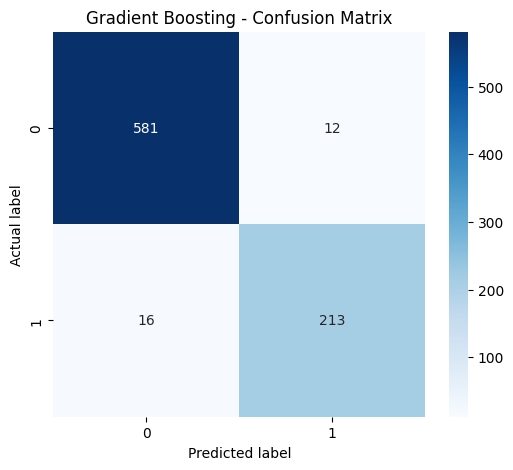

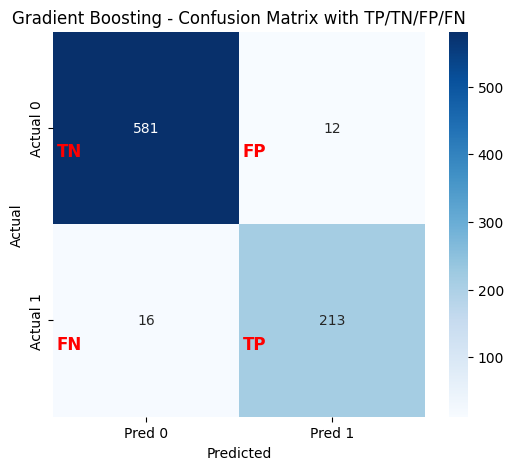

In [18]:
# Confusion matrices for BOTH models: LogisticRegression and GradientBoosting

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_for_model(model, model_name, X_test, y_test):
    # Predict
    y_pred = model.predict(X_test)
    
    # Classification report
    print(f"=== {model_name} - Classification Report ===")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{model_name} - Confusion Matrix (numeric):\n", cm)
    
    # Labels for axes
    unique_labels = np.unique(y_test)
    tick_labels = [str(l) for l in unique_labels]
    
    # Basic numeric heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=tick_labels, yticklabels=tick_labels)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted label')
    plt.ylabel('Actual label')
    plt.show()
    
    # If binary (0/1), add TP/TN/FP/FN labels in a second plot
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
        labels = np.array([["TN", "FP"],
                           ["FN", "TP"]])
        
        plt.figure(figsize=(6,5))
        ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                         xticklabels=['Pred 0','Pred 1'],
                         yticklabels=['Actual 0','Actual 1'])
        
        # overlay TN/FP/FN/TP labels in red
        for i in range(2):
            for j in range(2):
                ax.text(j+0.02, i+0.65, labels[i,j],
                        color='red', fontsize=12, fontweight='bold')
        
        plt.title(f'{model_name} - Confusion Matrix with TP/TN/FP/FN')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()


# ---- Run for BOTH models ----
plot_confusion_for_model(best_lr, "Logistic Regression", X_test, y_test)
plot_confusion_for_model(best_gb, "Gradient Boosting", X_test, y_test)


In [ ]:
# Cell 14 - Show predictions for first 5 test rows
#use gb model
sample = X_test.iloc[:5].copy()
sample_actual = y_test.iloc[:5].copy()
pred = best_gb.predict(sample)
probs = best_gb.predict_proba(sample)[:,1] if hasattr(best_gb, 'predict_proba') else None
out = sample.copy()
out['actual'] = sample_actual.values
out['pred'] = pred
if probs is not None:
    out['pred_prob_positive'] = probs
display(out)


,Age,Sleep_Hours,Screen_Time,Stress_Level,Noise_Exposure,Social_Interaction,Work_Hours,Exercise_Hours,Caffeine_Intake,Multitasking_Habit,Anxiety_Score,Depression_Score,Sensory_Sensitivity,Meditation_Habit,Overthinking_Score,Irritability_Score,Headache_Frequency,Sleep_Quality,Tech_Usage_Hours,Overstimulated,Heart_Rate,GPA,Prev_GPA,GPA_trend,Modules,Assignments_total,Deadlines_next_7_days,Assignment_weight_avg_pct,Study_hours_per_day,Attendance_pct,actual,pred,pred_prob_positive
2588,24,6.482215,5.929171,8,1,3,12,2.999450,4,1,6,4,4,0,8,7,6,4,3.808283,1,90.5,2.38,2.49,-0.11,7,20,2,58.5,1.98,63.8,1,1,0.995439
3290,28,6.248088,5.101858,7,4,5,6,0.241109,3,1,3,2,3,1,1,7,6,3,6.332727,1,85.3,2.08,1.98,0.10,6,14,1,52.4,2.97,70.6,0,0,0.000005
3846,23,7.816303,5.039279,9,1,1,7,1.828892,3,0,4,1,3,0,2,5,2,3,5.767950,1,93.6,2.18,2.42,-0.24,6,20,2,65.4,1.86,71.5,0,0,0.001947
447,22,9.611140,3.847947,7,4,1,6,2.380325,0,1,7,4,3,1,6,1,6,2,6.872176,0,80.2,2.77,2.95,-0.18,4,6,1,52.8,3.22,69.3,0,0,0.111922
3715,29,8.182098,8.491279,7,4,9,4,2.364925,4,0,9,4,1,0,4,5,2,1,3.026887,1,83.2,2.61,2.28,0.33,4,10,2,46.8,2.43,73.0,1,0,0.342539


GPA                          0.238481
Anxiety_Score                0.220028
Depression_Score             0.150548
Stress_Level                 0.117801
Overthinking_Score           0.072878
Sleep_Quality                0.044687
Sleep_Hours                  0.038413
GPA_trend                    0.037790
Attendance_pct               0.026477
Overstimulated               0.013966
Heart_Rate                   0.008793
Tech_Usage_Hours             0.006397
Assignments_total            0.005268
Assignment_weight_avg_pct    0.004845
Exercise_Hours               0.002682
Deadlines_next_7_days        0.002461
Prev_GPA                     0.001615
Work_Hours                   0.001479
Study_hours_per_day          0.001199
Caffeine_Intake              0.000891
Screen_Time                  0.000662
Modules                      0.000558
Noise_Exposure               0.000433
Age                          0.000375
Meditation_Habit             0.000307
Headache_Frequency           0.000275
Irritability

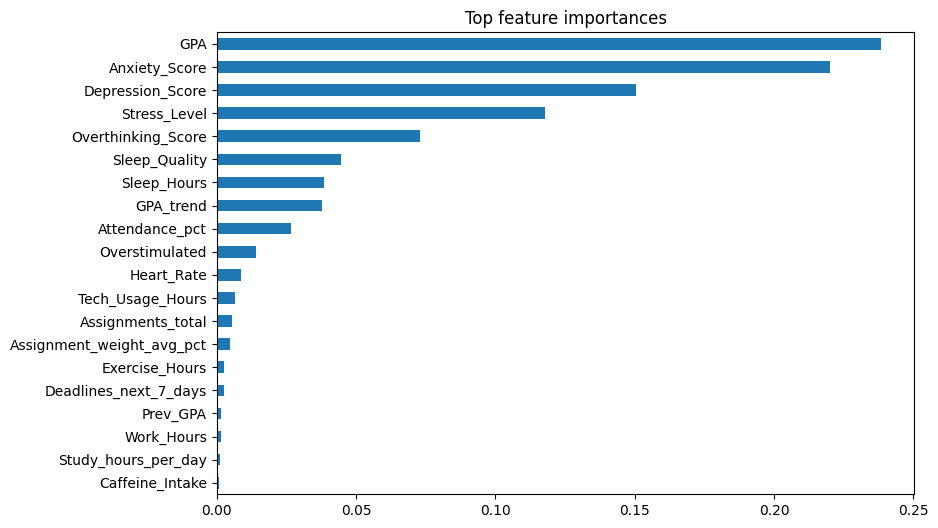

In [20]:
# Cell 15 - Feature importance (for tree model)
# extract feature names after preprocessing (works if no one-hot or with sklearn>=1.0 get_feature_names_out)
# Here we attempt to reconstruct names conservatively
try:
    pre = best_gb.named_steps['pre']
    # get numeric names
    num_names = num_cols
    cat_names = []
    if hasattr(pre, 'named_transformers_') and 'cat' in pre.named_transformers_:
        ohe = pre.named_transformers_['cat'].named_steps.get('ohe')
        if ohe is not None:
            cat_names = list(ohe.get_feature_names_out(cat_cols))
    final_feature_names = num_names + cat_names
except Exception:
    final_feature_names = FEATURES

clf = best_gb.named_steps['clf'] if hasattr(best_gb, 'named_steps') else best_gb
if hasattr(clf, 'feature_importances_'):
    fi = pd.Series(clf.feature_importances_, index=final_feature_names).sort_values(ascending=False)
    display(fi.head(30))
    fi.head(20)[::-1].plot(kind='barh'); plt.title('Top feature importances'); plt.show()
else:
    print('No feature_importances_ available for estimator.')


In [21]:
# Cell 16 - Save model, label generation config and metadata
meta = {
    'labeling_method': LABEL_CHOICE,
    'weights_used': weights if LABEL_CHOICE == 'weighted' else None,
    'BINARY_THRESHOLD': BINARY_THRESHOLD if LABEL_CHOICE == 'weighted' else None,
    'random_state': RANDOM_STATE,
    'date_utc': datetime.datetime.utcnow().isoformat(),
    'features_used': FEATURES
}
joblib.dump({'model': best_gb, 'meta': meta}, os.path.join(SAVE_DIR, 'behavior_model_synthetic_labels.joblib'))
with open(os.path.join(SAVE_DIR, 'labeling_metadata.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved artifacts to', SAVE_DIR)


Saved artifacts to Data/model_artifacts


In [22]:
# Cell 17 - Inference wrapper
def load_behavior_model(path=os.path.join(SAVE_DIR, 'behavior_model_synthetic_labels.joblib')):
    data = joblib.load(path)
    return data['model'], data['meta']

def predict_behavior_batch(model, X_df):
    y_pred = model.predict(X_df)
    y_prob = model.predict_proba(X_df)[:,1] if hasattr(model, 'predict_proba') else None
    out = X_df.copy()
    out['pred'] = y_pred
    if y_prob is not None:
        out['prob_pos'] = y_prob
    return out

model_loaded, meta_loaded = load_behavior_model()
print('Loaded meta:', meta_loaded)
print('Predicting 5 test records:')
display(predict_behavior_batch(model_loaded, X_test.iloc[:5]))


Loaded meta: {'labeling_method': 'weighted', 'weights_used': {'Stress_Level': 0.18, 'Anxiety_Score': 0.18, 'Depression_Score': 0.15, 'Overthinking_Score': 0.1, 'Sleep_Hours': -0.1, 'Sleep_Quality': -0.08, 'GPA_trend': -0.08, 'Attendance_pct': -0.05, 'Overstimulated': 0.04, 'Caffeine_Intake': 0.02, 'Tech_Usage_Hours': 0.02, 'Assignments_total': 0.02, 'Deadlines_next_7_days': 0.02}, 'BINARY_THRESHOLD': 60.0, 'random_state': 42, 'date_utc': '2025-12-10T16:12:47.281084', 'features_used': ['Age', 'Sleep_Hours', 'Screen_Time', 'Stress_Level', 'Noise_Exposure', 'Social_Interaction', 'Work_Hours', 'Exercise_Hours', 'Caffeine_Intake', 'Multitasking_Habit', 'Anxiety_Score', 'Depression_Score', 'Sensory_Sensitivity', 'Meditation_Habit', 'Overthinking_Score', 'Irritability_Score', 'Headache_Frequency', 'Sleep_Quality', 'Tech_Usage_Hours', 'Overstimulated', 'Heart_Rate', 'GPA', 'Prev_GPA', 'GPA_trend', 'Modules', 'Assignments_total', 'Deadlines_next_7_days', 'Assignment_weight_avg_pct', 'Study_hour

,Age,Sleep_Hours,Screen_Time,Stress_Level,Noise_Exposure,Social_Interaction,Work_Hours,Exercise_Hours,Caffeine_Intake,Multitasking_Habit,Anxiety_Score,Depression_Score,Sensory_Sensitivity,Meditation_Habit,Overthinking_Score,Irritability_Score,Headache_Frequency,Sleep_Quality,Tech_Usage_Hours,Overstimulated,Heart_Rate,GPA,Prev_GPA,GPA_trend,Modules,Assignments_total,Deadlines_next_7_days,Assignment_weight_avg_pct,Study_hours_per_day,Attendance_pct,pred,prob_pos
2588,24,6.482215,5.929171,8,1,3,12,2.999450,4,1,6,4,4,0,8,7,6,4,3.808283,1,90.5,2.38,2.49,-0.11,7,20,2,58.5,1.98,63.8,1,0.995439
3290,28,6.248088,5.101858,7,4,5,6,0.241109,3,1,3,2,3,1,1,7,6,3,6.332727,1,85.3,2.08,1.98,0.10,6,14,1,52.4,2.97,70.6,0,0.000005
3846,23,7.816303,5.039279,9,1,1,7,1.828892,3,0,4,1,3,0,2,5,2,3,5.767950,1,93.6,2.18,2.42,-0.24,6,20,2,65.4,1.86,71.5,0,0.001947
447,22,9.611140,3.847947,7,4,1,6,2.380325,0,1,7,4,3,1,6,1,6,2,6.872176,0,80.2,2.77,2.95,-0.18,4,6,1,52.8,3.22,69.3,0,0.111922
3715,29,8.182098,8.491279,7,4,9,4,2.364925,4,0,9,4,1,0,4,5,2,1,3.026887,1,83.2,2.61,2.28,0.33,4,10,2,46.8,2.43,73.0,0,0.342539


In [23]:
# Force sample prediction table to include both classes (0 and 1)

import pandas as pd
import numpy as np

# indices for each class
idx_0 = y_test[y_test == 0].index
idx_1 = y_test[y_test == 1].index

# sample 5 from each class (if available)
np.random.seed(42)
sample_0 = np.random.choice(idx_0, size=5, replace=False)
sample_1 = np.random.choice(idx_1, size=5, replace=False)

# combine indices
sample_idx = np.concatenate([sample_0, sample_1])

# get data
X_sample = X_test.loc[sample_idx]
y_actual = y_test.loc[sample_idx].reset_index(drop=True)

# predictions
lr_pred = best_lr.predict(X_sample)
gb_pred = best_gb.predict(X_sample)

# probabilities
lr_prob = best_lr.predict_proba(X_sample)[:,1]
gb_prob = best_gb.predict_proba(X_sample)[:,1]

# result table
results_df = pd.DataFrame({
    'Actual_Label': y_actual,
    'LR_Pred': lr_pred,
    'LR_Prob(HighBurnout)': lr_prob.round(3),
    'GB_Pred': gb_pred,
    'GB_Prob(HighBurnout)': gb_prob.round(3)
})

print("=== Sample Predictions from BOTH Classes (Balanced 5+5) ===")
display(results_df)


=== Sample Predictions from BOTH Classes (Balanced 5+5) ===


,Actual_Label,LR_Pred,LR_Prob(HighBurnout),GB_Pred,GB_Prob(HighBurnout)
0,0,0,0.000,0,0.000
1,0,0,0.000,0,0.118
2,0,0,0.000,0,0.000
3,0,0,0.000,0,0.000
4,0,0,0.000,0,0.024
5,1,1,1.000,1,0.998
6,1,1,0.932,0,0.339
7,1,1,1.000,1,0.994
8,1,1,1.000,1,1.000
9,1,1,0.998,1,0.553


In [25]:
# ------------------------------
# Model saving & artifact export
# Paste this after you've trained & evaluated models (best_gb, best_lr exist)
# ------------------------------
import os
import joblib
import json
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from pathlib import Path

SAVE_DIR = Path("saved_models_binary_high_v2_all")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 1) Save the full pipeline_with_preproc (best_gb is expected to be a pipeline)
pipeline_with_preproc = best_gb  # typically an imblearn Pipeline that includes preprocessor + clf
joblib.dump(pipeline_with_preproc, SAVE_DIR / "pipeline_with_preproc.pkl")
print("Saved pipeline_with_preproc.pkl")

# 2) Extract & save model-only (final estimator) if pipeline structure known
# Handles named_steps or steps list
def extract_model_from_pipeline(pipe):
    # try named_steps
    try:
        if hasattr(pipe, "named_steps") and "clf" in pipe.named_steps:
            return pipe.named_steps["clf"]
    except Exception:
        pass
    # try last step in steps
    try:
        if hasattr(pipe, "steps"):
            return pipe.steps[-1][1]
    except Exception:
        pass
    # fallback: return original object
    return pipe

final_model = extract_model_from_pipeline(pipeline_with_preproc)
joblib.dump(final_model, SAVE_DIR / "final_pipeline_lgbm.pkl")
print("Saved final_pipeline_lgbm.pkl (model-only)")

# 3) Save preprocessor if available (useful for mobile or separate transforms)
preprocessor_obj = None
try:
    # common key in our pipelines: 'pre'
    if hasattr(pipeline_with_preproc, "named_steps") and "pre" in pipeline_with_preproc.named_steps:
        preprocessor_obj = pipeline_with_preproc.named_steps["pre"]
    # fallback: if you have a separate 'preprocessor' variable
    elif 'preprocessor' in globals():
        preprocessor_obj = globals()['preprocessor']
except Exception:
    preprocessor_obj = None

if preprocessor_obj is not None:
    joblib.dump(preprocessor_obj, SAVE_DIR / "preprocessor.pkl")
    print("Saved preprocessor.pkl")

# 4) Save decision threshold by maximizing F1 on test set (uses pipeline.predict_proba)
decision_threshold = 0.5
try:
    if hasattr(pipeline_with_preproc, "predict_proba"):
        probs = pipeline_with_preproc.predict_proba(X_test)[:, 1]
    else:
        # try the extracted final model on preprocessed X_test
        # but need to transform X_test first with preprocessor
        if preprocessor_obj is not None and hasattr(final_model, "predict_proba"):
            X_test_trans = preprocessor_obj.transform(X_test)
            probs = final_model.predict_proba(X_test_trans)[:, 1]
        else:
            probs = None

    if probs is not None:
        thresholds = np.linspace(0.01, 0.99, 99)
        f1s = []
        for t in thresholds:
            preds = (probs >= t).astype(int)
            f1s.append(f1_score(y_test.astype(int), preds))
        best_idx = int(np.argmax(f1s))
        decision_threshold = float(thresholds[best_idx])
        print(f"Selected decision threshold by max F1: {decision_threshold:.3f} (F1={f1s[best_idx]:.3f})")
    else:
        print("Could not compute probabilities to select threshold; using default 0.5")
except Exception as e:
    print("Error computing decision threshold, using default 0.5:", e)
    decision_threshold = 0.5

joblib.dump(decision_threshold, SAVE_DIR / "decision_threshold.pkl")
print("Saved decision_threshold.pkl")

# 5) Save RandomizedSearchCV objects for reproducibility (if present)
try:
    if 'rs_gb' in globals():
        joblib.dump(rs_gb, SAVE_DIR / "rnd_search_gb.pkl")
        print("Saved rnd_search_gb.pkl")
    if 'rs_lr' in globals():
        joblib.dump(rs_lr, SAVE_DIR / "rnd_search_lr.pkl")
        print("Saved rnd_search_lr.pkl")
except Exception as e:
    print("Warning: failed to save randomized search objects:", e)

# 6) Save metadata JSON (labeling, features, random state, timestamp)
meta = {
    "labeling_method": globals().get("LABEL_CHOICE", None),
    "weights_used": globals().get("weights", None),
    "BINARY_THRESHOLD": globals().get("BINARY_THRESHOLD", None),
    "random_state": globals().get("RANDOM_STATE", None),
    "date_utc": pd.Timestamp.utcnow().isoformat(),
    "features_used": globals().get("FEATURES", None),
    "model_type": type(final_model).__name__
}
with open(SAVE_DIR / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved metadata.json")

# 7) Feature importances (if tree-based model) + feature name reconstruction
try:
    # reconstruct feature names conservatively (works with OneHotEncoder >=1.0)
    num_names = [c for c in X.columns if X[c].dtype.kind in 'fi']
    cat_names = []
    try:
        pre = preprocessor_obj
        if hasattr(pre, "named_transformers_") and "cat" in pre.named_transformers_:
            ohe = pre.named_transformers_['cat'].named_steps.get('ohe')
            cat_cols_local = [c for c in X.columns if c not in num_names]
            if ohe is not None and hasattr(ohe, "get_feature_names_out"):
                cat_names = list(ohe.get_feature_names_out(cat_cols_local))
    except Exception:
        cat_names = []

    final_feature_names = num_names + cat_names if (num_names or cat_names) else globals().get("FEATURES", None)

    if hasattr(final_model, "feature_importances_") and final_feature_names is not None:
        fi = pd.Series(final_model.feature_importances_, index=final_feature_names).sort_values(ascending=False)
        fi.to_csv(SAVE_DIR / "feature_importances.csv", header=["importance"])
        print("Saved feature_importances.csv")
    else:
        print("No feature_importances_ or couldn't reconstruct feature names; skipping feature_importances.csv")
except Exception as e:
    print("Warning while saving feature importances:", e)

# 8) Save test predictions with probabilities for inspection
try:
    preds = pipeline_with_preproc.predict(X_test)
    if hasattr(pipeline_with_preproc, "predict_proba"):
        probs = pipeline_with_preproc.predict_proba(X_test)[:, 1]
    else:
        # attempt model-only probability with preprocessor
        if preprocessor_obj is not None and hasattr(final_model, "predict_proba"):
            probs = final_model.predict_proba(preprocessor_obj.transform(X_test))[:, 1]
        else:
            probs = [None] * len(preds)

    results_df = X_test.copy().reset_index(drop=True)
    results_df["actual"] = y_test.reset_index(drop=True)
    results_df["pred"] = preds
    results_df["prob_pos"] = np.round(probs, 6) if probs is not None else None

    results_df.to_csv(SAVE_DIR / "test_predictions_with_probs.csv", index=False)
    print("Saved test_predictions_with_probs.csv")
except Exception as e:
    print("Warning while saving test predictions:", e)

print("\nAll artifacts saved to:", SAVE_DIR.resolve())


Saved pipeline_with_preproc.pkl
Saved final_pipeline_lgbm.pkl (model-only)
Saved preprocessor.pkl
Selected decision threshold by max F1: 0.500 (F1=0.938)
Saved decision_threshold.pkl
Saved rnd_search_gb.pkl
Saved rnd_search_lr.pkl
Saved metadata.json
Saved feature_importances.csv
Saved test_predictions_with_probs.csv

All artifacts saved to: C:\Users\94772\Desktop\ResearchBurnout\saved_models_binary_high_v2_all
